In [1]:
pip install numpy matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install open3d

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install laspy[lazrs,laszip]

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install rasterio

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install shapely alphashape

Note: you may need to restart the kernel to use updated packages.


In [8]:
# Base libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt

# 3D libraries
import open3d as o3d
# to manipulate 3d point clouds
import laspy
print(laspy.__version__)

# Geospatial libraries
import rasterio
import alphashape as ash
import geopandas as gpd
import shapely as sh

from rasterio.transform import from_origin
from rasterio.enums import Resampling
from rasterio.features import shapes
from shapely.geometry import Polygon

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
2.7.0


In [9]:
import os
os.environ["XDG_SESSION_TYPE"] = "x11"

In [10]:
# Neighborhood point cloud
las = laspy.read('DATA/neighborhood.laz')

# accesses the pre-assigned category labels (the column called "classifications") for every single point in the LiDAR file
# np.unique <-- filters the duplicates and prints a short list
print(np.unique(las.classification))

# prints column headers
print([dimension.name for dimension in las.point_format.dimensions])

[1 2 3 5 6 7]
['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue']


In [11]:
# Look through all the VLRs in the file
for i, vlrs in enumerate(las.vlrs):
    print(f"Index [{i}]: {vlrs.description} (Record ID: {vlrs.record_id})")
# WKT <-- Well-Known Text, a text markup language for representing vector geometry objects on a map (the data we need)

Index [0]: Local Time: 2023 02 24 17 58 18 (Record ID: 5)
Index [1]: Local Time: 2023 02 24 17 58 15 (Record ID: 8)
Index [2]: WKT (Time: 2023 02 24 17 58 15) (Record ID: 2112)


In [12]:
# Explore CRS (Coordinate Reference System) info
# vlrs = Variable Length Records, which are metadata records that can be included in a LAS file. They can contain various types of information, including the CRS information.
crs = las.vlrs[2].string
print(crs)

# projection system <-- flattening 3D globe into a 2D image
# this introduces certain distortion, but different projections minimize different types of distortion
# EPSG:26910 or NAD_1983_UTM_Zone_10N <-- Universal Transverse Mercator (UTM) projection minimizes distortion in areas with north-south orientation

PROJCS["NAD_1983_UTM_Zone_10N",GEOGCS["GCS_North_American_1983",DATUM["D_North_American_1983",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["False_Easting",500000.0],PARAMETER["False_Northing",0.0],PARAMETER["Central_Meridian",-123.0],PARAMETER["Scale_Factor",0.9996],PARAMETER["Latitude_Of_Origin",0.0],UNIT["Meter",1.0],AUTHORITY["EPSG",26910]]


In [13]:
# Create a mask to filter points
pts_mask = las.classification == 6

# Transform that into numpy array and use np.vstack() to stack the points vertically
xyz_t = np.vstack((las.x[pts_mask], las.y[pts_mask], las.z[pts_mask]))

In [14]:
# Transform to Open3D.o3d.geometry.PointCloud and visualize
pcd_o3d = o3d.geometry.PointCloud()
pcd_o3d.points = o3d.utility.Vector3dVector(xyz_t.transpose())

In [15]:
# Visualize the results
o3d.visualization.draw_geometries([pcd_o3d])

In [16]:
# Isolating ground points
pts_mask = las.classification == 2

xyz_t = np.vstack((las.x[pts_mask], las.y[pts_mask], las.z[pts_mask]))

ground_pts = o3d.geometry.PointCloud()
ground_pts.points = o3d.utility.Vector3dVector(xyz_t.transpose())
# Calculate the geometric center of the point cloud
pcd_center = ground_pts.get_center()
# Move the point cloud to the 0, 0, 0 origin <-- as the data comes from real-world, xy coordinates are massive numbers, rendering them can glitch, hence we translate them
ground_pts.translate(-pcd_center)

# Visualize the results
o3d.visualization.draw_geometries([ground_pts])

In [17]:
# Identifying the average distance between building points
nn_distance = np.mean(pcd_o3d.compute_nearest_neighbor_distance())
print("average point distance (m):", nn_distance)

average point distance (m): 0.11673857611056317


In [18]:
# DBSCAN - to carry unsupervised segmentation and filter noise
# two parameters required by DBSCAN
epsilon = 2
min_cluster_points = 100

In [19]:
# Each point receives a label corresponding to a specific cluster or is tagged as noise
labels = np.array(pcd_o3d.cluster_dbscan(eps=epsilon, min_points=min_cluster_points))

# To get the number of clusters created
max_label = labels.max()
print(f"point cloud has {max_label + 1} clusters")

point cloud has 31 clusters


In [20]:
# Discrete color palette to randomize the visualization
# tab20 <-- to get discrete colors
colors = plt.get_cmap("tab20")(labels / (max_label if max_label > 0 else 1))
colors[labels < 0] = 0
pcd_o3d.colors = o3d.utility.Vector3dVector(colors[:, :3])

# Visualize
o3d.visualization.draw_geometries([pcd_o3d])

In [21]:
# Single house segmentation
# Selecting a segment (the house) to be considered
sel = 1
# to instance segment, we use the select_by_index() method of the Open3D
segment = pcd_o3d.select_by_index(np.where(labels==sel)[0])

# Visualize the results
o3d.visualization.draw_geometries([segment])

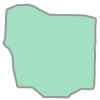

In [22]:
# Extracting the xy coordinates of our point cloud
points_2D = np.asarray(segment.points)[:,0:2]

# We compute the alpha shape and return the result with shapely
building_vector = ash.alphashape(points_2D, alpha=0.5)
building_vector

In [23]:
# Storing the 2D polygon in a GeoDataFrame
building_gdf = gpd.GeoDataFrame(geometry=[building_vector], crs='EPSG:26910')
building_gdf.head(1)

,geometry
0,"POLYGON ((490241.032 5453727.465, 490241.113 5..."


In [24]:
# To calculate the altitude (height) of the building, we use the ground points which we had extracted
# we use query_point to get the center of the segment and then set its z-coordinate to the minimum bound of the segment, which represents the ground level of the building. 
# This allows us to determine the height of the building by comparing the z-coordinates of the segment points with this ground level.
query_point = segment.get_center()
query_point[2] = segment.get_min_bound()[2]

# k-d tree to construct the ground points for the building segment
pcd_tree = o3d.geometry.KDTreeFlann(ground_pts)

# k-NN search to find the nearest ground point to the query point
[k, idx, _] = pcd_tree.search_knn_vector_3d(query_point, 200)

In [25]:
# from nn search we extract the points that belong to the ground and paint them grey
sample = ground_pts.select_by_index(idx, invert=False)
sample.paint_uniform_color([0.5, 0.5, 0.5])
o3d.visualization.draw_geometries([sample, ground_pts])

In [26]:
# Extract the mean value of the ground in the specific place
ground_zero = sample.get_center()[2]

# Compute the height of the building, roof included
height = segment.get_max_bound()[2] - segment.get_min_bound()[2]
print("Building height (m):", height)

Building height (m): 10.192000000000007


In [27]:
# Computing other quantifiable attributes
building_gdf[['id']] = sel

In [28]:
# Computing object based properties
building_gdf[['height']] = segment.get_max_bound()[2] - sample.get_center()[2]
building_gdf[['area']] = building_vector.area
building_gdf[['perimeter']] = building_vector.length

# Retrieve the local centroid coordinates, segment center, and number of points
building_gdf[['local_cx', 'local_cy', 'local_cz']] = np.asarray([building_vector.centroid.x, building_vector.centroid.y, sample.get_center()[2]])
building_gdf[['transl_x', 'transl_y', 'transl_z']] = pcd_center
building_gdf[['pts_number']] = len(segment.points)

building_gdf.head(1)

,geometry,id,height,area,perimeter,local_cx,local_cy,local_cz,transl_x,transl_y,transl_z,pts_number
0,"POLYGON ((490241.032 5453727.465, 490241.113 5...",1,118.799688,217.077529,58.1788,490233.308893,5.453727e+06,-3.983688,490277.006386,5.453747e+06,103.160878,7747


The local minima (along the Z axis) 104.624
The local maxima (along the Z axis) 114.816


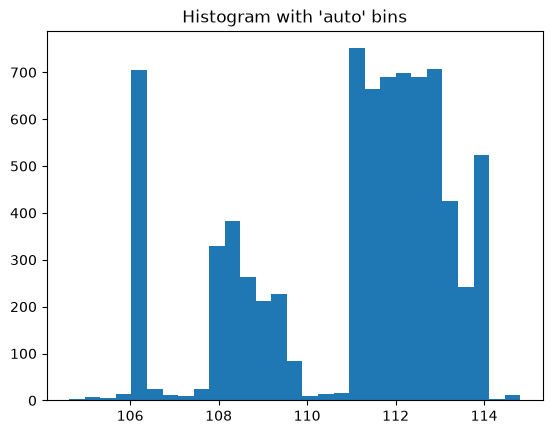

In [29]:
# Extracting extra attributes
points_1D = np.asarray(segment.points)[:,2]
print('The local minima (along the Z axis)', np.min(points_1D))
print('The local maxima (along the Z axis)', np.max(points_1D))

# Plotting the histogram - to extract ways to model the roof layers
plt.hist(points_1D, bins='auto')
plt.title("Histogram with 'auto' bins")
plt.show()

In [30]:
# Transforming our 2D shape into a 3D model
# Compute the 2D polygon
# Generate the vertex list
vertices = list(building_vector.exterior.coords)

# Construct the Open3D object
polygon_2d = o3d.geometry.LineSet()
polygon_2d.points = o3d.utility.Vector3dVector([point + (0,) for point in vertices])
polygon_2d.lines = o3d.utility.Vector2iVector([(i, (i + 1) % len(vertices)) for i in range(len(vertices))])

# Generate the same for the extruded
extrusion = o3d.geometry.LineSet()
extrusion.points = o3d.utility.Vector3dVector([point + (height,) for point in vertices])
extrusion.lines = o3d.utility.Vector2iVector([(i, (i + 1) % len(vertices)) for i in range(len(vertices))])

o3d.visualization.draw_geometries([polygon_2d, extrusion])

In [31]:
# Plot the vertices
temp = polygon_2d + extrusion
temp.points
temp_o3d = o3d.geometry.PointCloud()
temp_o3d.points = temp.points
o3d.visualization.draw_geometries([temp_o3d])

In [32]:
# Generating the base vertices for the 3D mesh with NumPy
a = np.array(building_vector.exterior.coords)
b = np.ones([a.shape[0],1]) * sample.get_center()[2]
c = np.ones([a.shape[0],1]) * (sample.get_center()[2] + height)

# Define the ground footprint and the height arrays of points
ground_pc = np.hstack((a, b))
up_pc = np.hstack((a, c))

# Generate an Open3D point cloud made of the major points
temp_o3d = o3d.geometry.PointCloud()
temp_o3d.points = o3d.utility.Vector3dVector(np.concatenate((ground_pc, up_pc), axis=0))

o3d.visualization.draw_geometries([temp_o3d])

In [33]:
# Compute the alpha shape of the 3D base points
alpha = 20
mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(segment, alpha)

mesh.compute_vertex_normals()
mesh.paint_uniform_color([0.5, 0.4, 0])
o3d.visualization.draw_geometries([temp_o3d, mesh, segment], mesh_show_back_face=True)

# Postprocessing operations and export
# Repositioning the mesh from local to the world coordinates
mesh.translate(pcd_center)

# Export the mesh
o3d.io.write_triangle_mesh('RESULTS/house_sample.ply', mesh, write_ascii=False, compressed=True, write_vertex_normals=False, write_vertex_colors=False, write_triangle_uvs=False)

# Export the shapefile
building_gdf.to_file("RESULTS/single_building.shp")


Qhull messages at ~Qhull()
QH7089 qhull precision warning: The initial hull is narrow.  Is the input lower
dimensional (e.g., a square in 3-d instead of a cube)?  Cosine of the minimum
angle is 0.9999999999999997.  If so, Qhull may produce a wide facet.
Options 'Qs' (search all points), 'Qbb' (scale last coordinate), or
'QbB' (scale to unit box) may remove this warning.
See 'Limitations' in qh-impre.htm.  Use 'Pp' to skip this warning.


[Open3D WARNING] [CreateFromPointCloudAlphaShape] alpha shape reconstruction resulted in empty mesh. Alpha value (20) could be too small.
[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.
[Open3D WARNING] Write PLY failed: mesh has 0 vertices.


In [34]:
# Estimate normals for the segment (crucial for Poisson)
segment.estimate_normals(
    search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=1.0, max_nn=30)
)

# Run Poisson reconstruction
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
    segment, depth=9
)

# Clean up sparse outlier triangles
vertices_to_remove = densities < np.quantile(densities, 0.05)
mesh.remove_vertices_by_mask(vertices_to_remove)

# Now export successfully
o3d.io.write_triangle_mesh('RESULTS/house_sample.ply', mesh)

True

In [ ]:
building_dataframes = []

# Automation and Scaling
for sel in range(max_label+1):
    segment = pcd_o3d.select_by_index(np.where(labels==sel)[0])

    # compute building footprint
    altitude = np.asarray(segment.points)[:,2]+pcd_center[2]
    points_2D = np.asarray(segment.points)[:,0:2]
    building_vector = ash.alphashape(points_2D, alpha=0.5)

    # compute height of the segment
    query_point = segment.get_center()
    query_point[2] = segment.get_min_bound()[2]
    pcd_tree = o3d.geometry.KDTreeFlann(ground_pts)
    [k, idx, _] = pcd_tree.search_knn_vector_3d(query_point, 50)
    sample = ground_pts.select_by_index(idx, invert=False)
    ground_zero = sample.get_center()[2]

    # create geopandas with attributes entry
    building_gdf = gpd.GeoDataFrame(geometry=[building_vector], crs='EPSG:26910')
    building_gdf[['id']] = sel
    building_gdf[['height']] = segment.get_max_bound()[2] - sample.get_center()[2]
    building_gdf[['area']] = building_vector.area
    building_gdf[['perimeter']] = building_vector.length
    building_gdf[['local_cx', 'local_cy', 'local_cz']] = np.asarray([building_vector.centroid.x, building_vector.centroid.y, sample.get_center()[2]])
    building_gdf[['transl_x', 'transl_y', 'transl_z']] = pcd_center
    building_gdf[['pts_number']] = len(segment.points)


    # Add geomerties entries
    building_dataframes.append(building_gdf) 

    a = np.array(building_vector.exterior.coords)
    b = np.ones([a.shape[0],1]) * sample.get_center()[2]
    height = segment.get_max_bound()[2] - sample.get_center()[2]
    c = np.ones([a.shape[0],1]) * (sample.get_center()[2] + height)
    ground_pc = np.hstack((a, b))
    up_pc = np.hstack((a, c))
    temp_o3d = o3d.geometry.PointCloud()
    temp_o3d.points = o3d.utility.Vector3dVector(np.concatenate((ground_pc, up_pc), axis=0))

    alpha = 20
    mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(temp_o3d, alpha)

    mesh.compute_vertex_normals()
    mesh.paint_uniform_color([0.5, 0.4, 0])
    # o3d.visualization.draw_geometries([temp_o3d, mesh, segment], mesh_show_back_face=True)
    mesh.translate(pcd_center)
    o3d.io.write_triangle_mesh(f'RESULTS/house_{sel}.ply', mesh, write_ascii=False, compressed=True, write_vertex_normals=False, write_vertex_colors=False, write_triangle_uvs=False)

buildings_gdf = pd.concat(building_dataframes, ignore_index=True)
buildings_gdf.to_file("RESULTS/all_buildings.shp")
    

[Open3D WARNING] [CreateFromPointCloudAlphaShape] alpha shape reconstruction resulted in empty mesh. Alpha value (20) could be too small.
[Open3D WARNING] Write PLY failed: mesh has 0 vertices.



Qhull messages at ~Qhull()
QH7089 qhull precision warning: The initial hull is narrow.  Is the input lower
dimensional (e.g., a square in 3-d instead of a cube)?  Cosine of the minimum
angle is 0.9999999999999997.  If so, Qhull may produce a wide facet.
Options 'Qs' (search all points), 'Qbb' (scale last coordinate), or
'QbB' (scale to unit box) may remove this warning.
See 'Limitations' in qh-impre.htm.  Use 'Pp' to skip this warning.


[Open3D WARNING] [CreateFromPointCloudAlphaShape] alpha shape reconstruction resulted in empty mesh. Alpha value (20) could be too small.
[Open3D WARNING] Write PLY failed: mesh has 0 vertices.


RuntimeError: QH6298 Qhull precision error (qh_check_maxout): a facet merge, vertex merge, vertex, or coplanar point produced a wide facet 0.00014 (1273.8x). Trace with option 'TWn' to identify the merge.   Allow with 'Q12' (allow-wide)

While executing:  | qhull d Qbb Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 1046882312  delaunay  Qbbound-last  Qtriangulate  _pre-merge
  _zero-centrum  Pgood  _max-width 8.2  Error-roundoff 1.1e-08
  _one-merge 9.9e-08  _near-inside 4.9e-07  Visible-distance 6.6e-08
  U-max-coplanar 6.6e-08  Width-outside 1.3e-07  _wide-facet 4e-07
  _narrow-hull 9.3e-14  _maxoutside 0.00014
Last point added to hull was p913.  Last merge was #1280.

At error exit:

Delaunay triangulation by the convex hull of 1850 points in 4-d:

  Number of input sites: 95
  Total number of deleted points due to merging: 38
  Total number of nearly incident points: 1717
  Number of Delaunay regions: 132
  Number of non-simplicial Delaunay regions: 68

Statistics for: